# Strict vs. Relaxed Match: What Is Lost at the Boundary?

**Feeds:** RQ1/RQ3 supplementary evidence -- quantifies how much apparent
unreliability is boundary imprecision (partial word-level matches) rather
than complete misses.

Uses `results/test/{portuguese,english}/results.csv` (`f1` vs `f1_r`) and
`detailed_results_token_level.csv` (`result_type` in {EXACT, PARTIAL, MISS},
`word_category`), for the best template per (model, language).


In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
best_templates = c.load_best_templates()
test_results = pd.concat([c.load_results("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_test = c.filter_to_best_templates(test_results, best_templates)
best_test[["language", "model", "template", "f1", "f1_r"]].sort_values(["language", "model"])


[filter_to_best_templates] english/qwen3_4b: prompt_selection best template ('cls_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
[filter_to_best_templates] portuguese/qwen3_4b: prompt_selection best template ('ext_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').


,language,model,template,f1,f1_r
3,english,gemini,cls_def_exp,0.540468,0.752367
4,english,gemma3_1b,ext_def_exp,0.155652,0.415651
5,english,llama32_3b,cls_exp,0.017229,0.008470
6,english,qwen25_14b,cls_exp,0.228795,0.674371
7,english,qwen3_4b,cls_def_exp,0.256082,0.597985
0,portuguese,gemini,cls_def_exp,0.558736,0.800158
1,portuguese,gemma3_1b,ext_def_exp,0.189520,0.543525
2,portuguese,qwen25_14b,cls_exp,0.232546,0.739365
8,portuguese,qwen3_4b,cls_def_exp,0.248721,0.657510


## F1 vs F1-r gap, by model and language

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\04_f1_vs_f1r_by_model_language.pdf


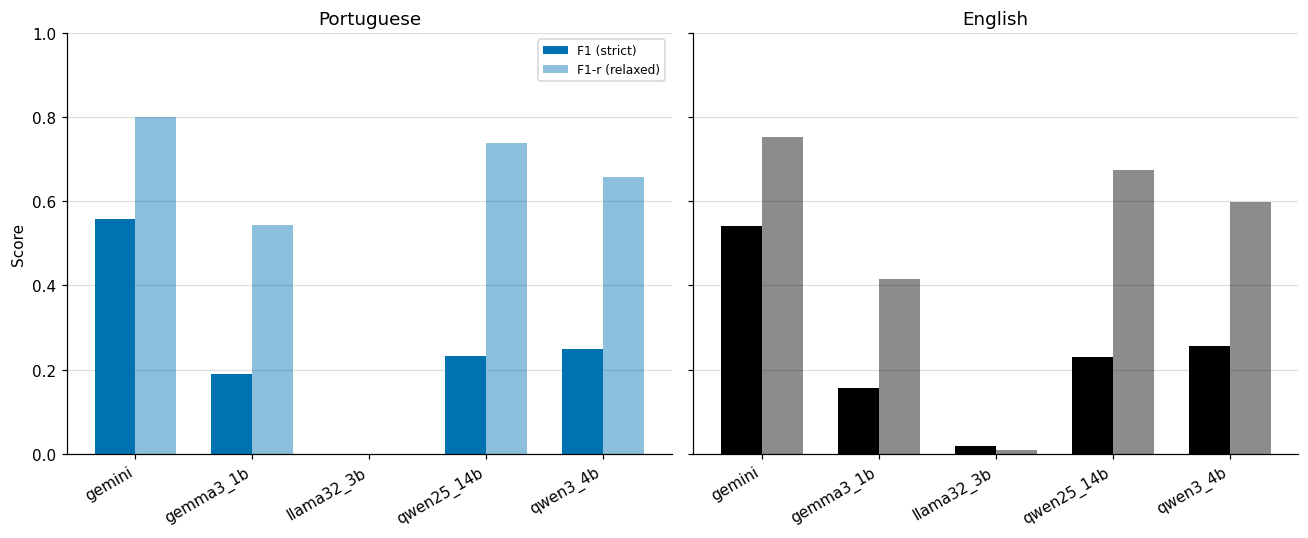

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = best_test[best_test["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
    x = np.arange(len(c.MODEL_ORDER))
    width = 0.35
    ax.bar(x - width / 2, sub["f1"], width=width, color=c.LANGUAGE_COLORS[lang], label="F1 (strict)")
    ax.bar(x + width / 2, sub["f1_r"], width=width, color=c.LANGUAGE_COLORS[lang], alpha=0.45, label="F1-r (relaxed)")
    ax.set_xticks(x)
    ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
    ax.set_title(lang.capitalize())
    ax.set_ylim(0, 1)
    c.style_axis(ax)
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)
c.save_fig(fig, "04_f1_vs_f1r_by_model_language")
plt.show()


In [4]:
best_test["gap"] = best_test["f1_r"] - best_test["f1"]
best_test[["language", "model", "f1", "f1_r", "gap"]].sort_values("gap", ascending=False)


,language,model,f1,f1_r,gap
2,portuguese,qwen25_14b,0.232546,0.739365,0.506819
6,english,qwen25_14b,0.228795,0.674371,0.445576
8,portuguese,qwen3_4b,0.248721,0.657510,0.408789
1,portuguese,gemma3_1b,0.189520,0.543525,0.354005
7,english,qwen3_4b,0.256082,0.597985,0.341903
4,english,gemma3_1b,0.155652,0.415651,0.260000
0,portuguese,gemini,0.558736,0.800158,0.241422
3,english,gemini,0.540468,0.752367,0.211899
5,english,llama32_3b,0.017229,0.008470,-0.008759


## Breakdown by match outcome (EXACT / PARTIAL / MISS)

In [5]:
token = pd.concat([c.load_detailed_token("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_token = c.filter_to_best_templates(token, best_templates)

outcome = best_token.groupby(["language", "model", "result_type"]).size().rename("n").reset_index()
outcome["pct"] = outcome["n"] / outcome.groupby(["language", "model"])["n"].transform("sum")
outcome.head()


[filter_to_best_templates] english/qwen3_4b: prompt_selection best template ('cls_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
[filter_to_best_templates] portuguese/qwen3_4b: prompt_selection best template ('ext_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').


,language,model,result_type,n,pct
0,portuguese,gemini,EXACT,3797,0.480086
1,portuguese,gemini,MISS,706,0.089265
2,portuguese,gemini,PARTIAL,3406,0.430649
3,portuguese,gemma3_1b,EXACT,1020,0.234645
4,portuguese,gemma3_1b,MISS,1091,0.250978


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\04_result_type_breakdown.pdf


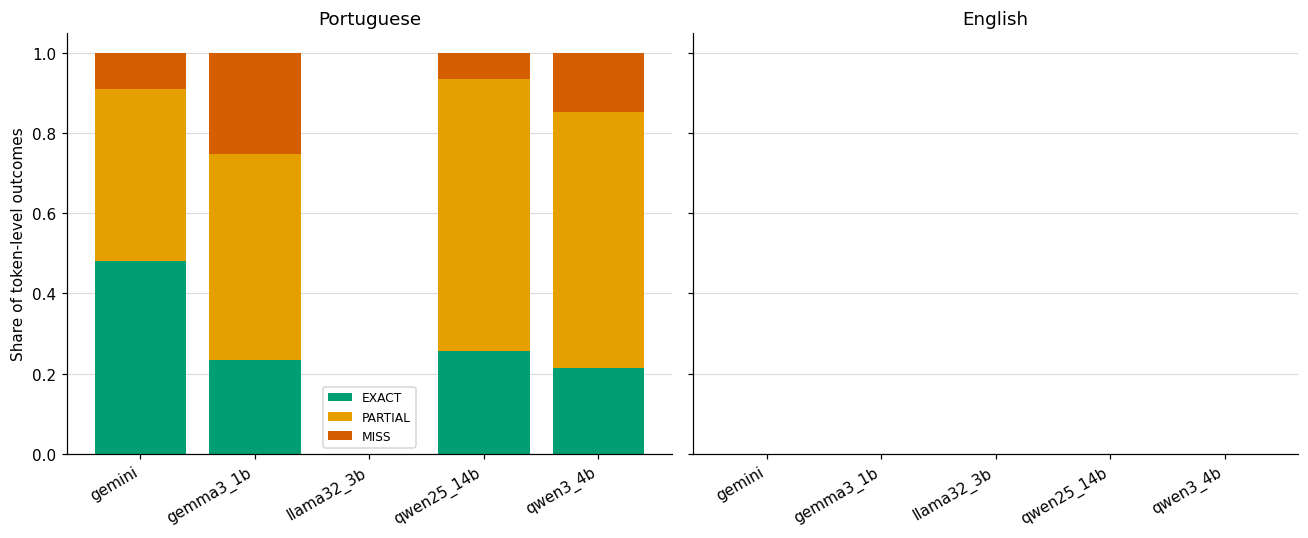

In [6]:
RESULT_TYPES = ["EXACT", "PARTIAL", "MISS"]
OUTCOME_COLORS = {"EXACT": "#009E73", "PARTIAL": "#E69F00", "MISS": "#D55E00"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    bottom = np.zeros(len(c.MODEL_ORDER))
    for rt in RESULT_TYPES:
        sub = outcome[(outcome["language"] == lang) & (outcome["result_type"] == rt)].set_index("model").reindex(c.MODEL_ORDER)
        vals = sub["pct"].fillna(0).values
        ax.bar(c.MODEL_ORDER, vals, bottom=bottom, color=OUTCOME_COLORS[rt], label=rt)
        bottom += vals
    ax.set_title(lang.capitalize())
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    c.style_axis(ax)
axes[0].set_ylabel("Share of token-level outcomes")
axes[0].legend(fontsize=8)
c.save_fig(fig, "04_result_type_breakdown")
plt.show()


## Top word categories driving partial-match loss

In [7]:
partial = best_token[best_token["result_type"] == "PARTIAL"]
top_categories = (
    partial.groupby("word_category").size().rename("n").sort_values(ascending=False).head(15).reset_index()
)
top_categories


,word_category,n
0,Nao definido,6597
1,Artigos,2715
2,Preposições e Contrações,1973
3,Substantivos Genéricos (Atores),428
4,Numerais e Quantificadores,265
5,Termos Espaciais e Jurisdicionais,250
6,Pronomes Demonstrativos/Possessivos,76


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\04_top_word_categories_partial.pdf


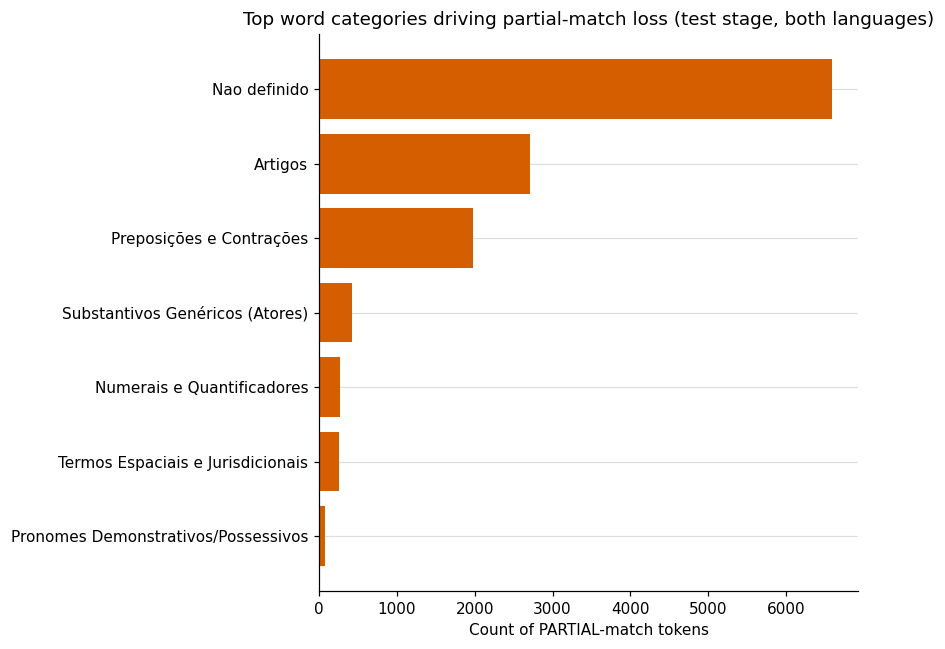

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
order = top_categories.sort_values("n")
ax.barh(order["word_category"], order["n"], color=c.MODEL_COLORS["qwen3_4b"])
ax.set_xlabel("Count of PARTIAL-match tokens")
ax.set_title("Top word categories driving partial-match loss (test stage, both languages)")
c.style_axis(ax)
c.save_fig(fig, "04_top_word_categories_partial")
plt.show()


## Synthesis

- Feeds **RQ1/RQ3** as supplementary evidence: a large F1-vs-F1-r gap means the model is finding roughly the right span but not the exact boundary -- a softer failure mode than a complete miss.
- The EXACT/PARTIAL/MISS breakdown separates "found it, imperfect boundary" from "found nothing", per model and language.
- The top word-category ranking identifies which lexical categories (e.g. determiners, prepositions) are most often the boundary words the model gets wrong.
